In [1]:
import sys

try:
    import torch
    print("Python:", sys.version)
    print("Torch:", torch.__version__)
    print("CUDA:", torch.version.cuda)
    print("GPU:", torch.cuda.is_available())
except Exception as e:
    print("Falha ao importar torch:", e)
    print("Sugestao: use Python 3.10/3.11 e reinstale PyTorch.")
    print("Exemplo (GPU): pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124")
    raise


Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
Torch: 2.11.0+cu126
CUDA: 12.6
GPU: True


In [2]:
import os
import torch
import pandas as pd

from SEConformer import (
    DEVICE,
    build_inbreast_csv,
    make_run_dirs,
    train_inbreast_all,
)

print("Device:", DEVICE)


Device: cuda


In [3]:
inbreast_csv = r"C:\\Users\\franc\\OneDrive\\Desktop\\Breast Cancer\\BrestCancer Datasets\\INBreast\\INbreast\\INbreast.csv"
dicom_dir = r"C:\\Users\\franc\\OneDrive\\Desktop\\Breast Cancer\\BrestCancer Datasets\\INBreast\\INbreast\\AllDICOMs"

# Cria o CSV com folds (Bi-Rads >=4 = maligno)
df = build_inbreast_csv(
    inbreast_csv,
    dicom_dir,
    out_csv="INbreast_Folds.csv",
    n_splits=5,
    random_state=42,
    birads_threshold=4,
)
print("Total imagens:", len(df))


CSV criado com sucesso! INbreast_Folds.csv
Total imagens: 410


100%|██████████| 17/17 [01:30<00:00,  5.33s/it]



Epoch 0 Loss: 0.7349 | Val Acc: 0.7647


100%|██████████| 17/17 [01:28<00:00,  5.20s/it]



Epoch 1 Loss: 0.5774 | Val Acc: 0.7647


100%|██████████| 17/17 [01:26<00:00,  5.10s/it]



Epoch 2 Loss: 0.5698 | Val Acc: 0.7647


100%|██████████| 17/17 [01:30<00:00,  5.35s/it]



Epoch 3 Loss: 0.5891 | Val Acc: 0.7647


100%|██████████| 17/17 [01:31<00:00,  5.40s/it]



Epoch 4 Loss: 0.5663 | Val Acc: 0.7647


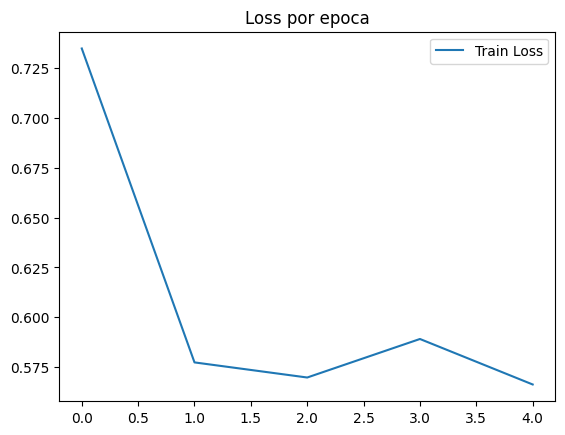

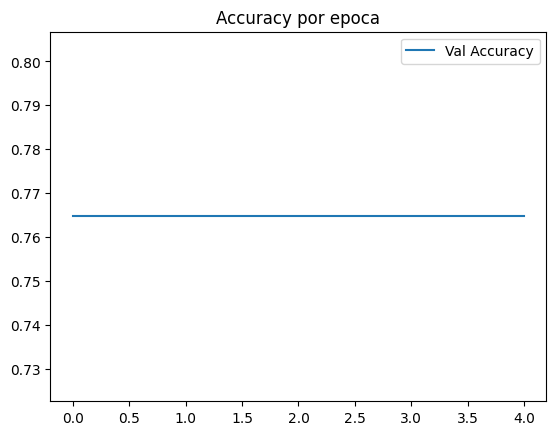

Salvo: results/SEConformer\seconformer_20260407-004351\history.csv
Salvo: results/SEConformer\seconformer_20260407-004351\models\seconformer.pt
Salvo: results/SEConformer\seconformer_20260407-004351\final_metrics.json
Run salvo em: results/SEConformer\seconformer_20260407-004351


In [6]:
# treino com TODO o dataset (com split interno para validacao)
run_dirs = make_run_dirs()

model, run_dirs = train_inbreast_all(
    "INbreast_Folds.csv",
    epochs=5,
    run_dirs=run_dirs,
    img_size=224,
    val_split=0.2
)

print("Run salvo em:", run_dirs["out_dir"])
